<a href="https://colab.research.google.com/github/nicolastibata/MINE_4206_AML_202610/blob/main/labs/lab_6/MINE_4206_AML_202610_L6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

![Logo AML](https://github.com/nicolastibata/MINE_4206_AML_202610/blob/main/docs/logo.jpg?raw=true)

# **Laboratorio 6: AutoML**
**Tutor: Nicolás Tibatá**

## **Tabla de Contenido**

[Contexto y objetivos](#scrollTo=R4YrUaE6udsU&line=14&uniqifier=1)<br>
[1. Introducción de los datos](#scrollTo=VjA8zwzJvmeO&line=1&uniqifier=1)<br>
[2. Preparación y Modelamiento](#scrollTo=kG8XHROzvuEH&line=1&uniqifier=1)<br>
[3. Preguntas](#scrollTo=HnWtjBcSv3yG&line=1&uniqifier=1)<br>


### **Contexto y Objetivos**

**Problema**
- En esta competencia el objetivo es predecir los valores de medición de la polución en el aire, se cuenta con información de temperatura y humedad y de 5 sensores espcíficos de medición.

- Existen 3 variables a predecir: `target_carbon_monoxide`, `target_benzene`, `target_nitrogen_oxides`.

Los datos se encuentran [aquí](https://www.kaggle.com/competitions/tabular-playground-series-jul-2021/data)

### **1. Introducción a los datos**

In [1]:
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "flaml"])

from flaml import AutoML

In [2]:
from google.colab import files
from google.colab import userdata

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
os.environ["KAGGLE_API_TOKEN"] = userdata.get('KAGGLE_API_TOKEN')

!kaggle competitions download -c tabular-playground-series-jul- # Antes de descargar los datos se deben aceptar las condiciones de la competencia de Kaggle.
# OJO no vamos a competir, solo usaremos ese dataset.
!unzip tabular-playground-series-jul-2021.zip

100% 264k/264k [00:00<00:00, 13.9MB/s]

Archive:  tabular-playground-series-jul-2021.zip
  inflating: sample_submission.csv   
  inflating: test.csv                
  inflating: train.csv               


In [39]:
train_data = pd.read_csv("/content/train.csv")
test_data = pd.read_csv("/content/test.csv")
targets =["target_carbon_monoxide","target_benzene","target_nitrogen_oxides"]

all_data = pd.concat([train_data,test_data],axis=0)
all_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9358 entries, 0 to 2246
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   date_time               9358 non-null   object 
 1   deg_C                   9358 non-null   float64
 2   relative_humidity       9358 non-null   float64
 3   absolute_humidity       9358 non-null   float64
 4   sensor_1                9358 non-null   float64
 5   sensor_2                9358 non-null   float64
 6   sensor_3                9358 non-null   float64
 7   sensor_4                9358 non-null   float64
 8   sensor_5                9358 non-null   float64
 9   target_carbon_monoxide  7111 non-null   float64
 10  target_benzene          7111 non-null   float64
 11  target_nitrogen_oxides  7111 non-null   float64
dtypes: float64(11), object(1)
memory usage: 950.4+ KB


In [40]:
all_data

,date_time,deg_C,relative_humidity,absolute_humidity,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,target_carbon_monoxide,target_benzene,target_nitrogen_oxides
0,2010-03-10 18:00:00,13.1,46.0,0.7578,1387.2,1087.8,1056.0,1742.8,1293.4,2.5,12.0,167.7
1,2010-03-10 19:00:00,13.2,45.3,0.7255,1279.1,888.2,1197.5,1449.9,1010.9,2.1,9.9,98.9
2,2010-03-10 20:00:00,12.6,56.2,0.7502,1331.9,929.6,1060.2,1586.1,1117.0,2.2,9.2,127.1
3,2010-03-10 21:00:00,11.0,62.4,0.7867,1321.0,929.0,1102.9,1536.5,1263.2,2.2,9.7,177.2
4,2010-03-10 22:00:00,11.9,59.0,0.7888,1272.0,852.7,1180.9,1415.5,1132.2,1.5,6.4,121.8
...,...,...,...,...,...,...,...,...,...,...,...,...
2242,2011-04-04 10:00:00,23.2,28.7,0.7568,1340.3,1023.9,522.8,1374.0,1659.8,NaN,NaN,NaN
2243,2011-04-04 11:00:00,24.5,22.5,0.7119,1232.8,955.1,616.1,1226.1,1269.0,NaN,NaN,NaN
2244,2011-04-04 12:00:00,26.6,19.0,0.6406,1187.7,1052.4,572.8,1253.4,1081.1,NaN,NaN,NaN
2245,2011-04-04 13:00:00,29.1,12.7,0.5139,1053.2,1009.0,702.0,1009.8,808.5,NaN,NaN,NaN


### **2. Preparación y Modelamiento**

#### **Preparación**

In [30]:
# Agregamos date features
def date_features(df):
  df_t = df.copy()
  df_t["date_time"] = pd.to_datetime(df_t["date_time"])
  df_t["year"] = df_t["date_time"].dt.year
  df_t["month"] = df_t["date_time"].dt.month
  df_t["day"] = df_t["date_time"].dt.day
  df_t["time"] = df_t["date_time"].dt.date - df_t["date_time"].dt.date.min()
  df_t["hour"] = df_t["date_time"].dt.hour
  df_t['time'] = df_t['time'].apply(lambda x : x.days)
  df_t["day_of_week"] = df_t["date_time"].dt.dayofweek
  df_t["day_of_week"] = df_t["day_of_week"].astype("object")
  df_t = pd.get_dummies(df_t, dtype=int) # Realizamos onehotencoder a day of week (no se especifica debido a que es la única var. categórica)
  df_t.drop(columns = 'date_time', inplace = True)
  return df_t

In [31]:
train_data_featured = date_features(train_data)
train_data_featured

,deg_C,relative_humidity,absolute_humidity,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,target_carbon_monoxide,target_benzene,...,day,time,hour,day_of_week_0,day_of_week_1,day_of_week_2,day_of_week_3,day_of_week_4,day_of_week_5,day_of_week_6
0,13.1,46.0,0.7578,1387.2,1087.8,1056.0,1742.8,1293.4,2.5,12.0,...,10,0,18,0,0,1,0,0,0,0
1,13.2,45.3,0.7255,1279.1,888.2,1197.5,1449.9,1010.9,2.1,9.9,...,10,0,19,0,0,1,0,0,0,0
2,12.6,56.2,0.7502,1331.9,929.6,1060.2,1586.1,1117.0,2.2,9.2,...,10,0,20,0,0,1,0,0,0,0
3,11.0,62.4,0.7867,1321.0,929.0,1102.9,1536.5,1263.2,2.2,9.7,...,10,0,21,0,0,1,0,0,0,0
4,11.9,59.0,0.7888,1272.0,852.7,1180.9,1415.5,1132.2,1.5,6.4,...,10,0,22,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7106,9.2,32.0,0.3871,1000.5,811.2,873.0,909.0,910.5,1.3,5.1,...,31,296,20,0,0,0,0,1,0,0
7107,9.1,33.2,0.3766,1022.7,790.0,951.6,912.9,903.4,1.4,5.8,...,31,296,21,0,0,0,0,1,0,0
7108,9.6,34.6,0.4310,1044.4,767.3,861.9,889.2,1159.1,1.6,5.2,...,31,296,22,0,0,0,0,1,0,0
7109,8.0,40.7,0.4085,952.8,691.9,908.5,917.0,1206.3,1.5,4.6,...,31,296,23,0,0,0,0,1,0,0


In [32]:
train_data_featured.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7111 entries, 0 to 7110
Data columns (total 23 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   deg_C                   7111 non-null   float64
 1   relative_humidity       7111 non-null   float64
 2   absolute_humidity       7111 non-null   float64
 3   sensor_1                7111 non-null   float64
 4   sensor_2                7111 non-null   float64
 5   sensor_3                7111 non-null   float64
 6   sensor_4                7111 non-null   float64
 7   sensor_5                7111 non-null   float64
 8   target_carbon_monoxide  7111 non-null   float64
 9   target_benzene          7111 non-null   float64
 10  target_nitrogen_oxides  7111 non-null   float64
 11  year                    7111 non-null   int32  
 12  month                   7111 non-null   int32  
 13  day                     7111 non-null   int32  
 14  time                    7111 non-null   

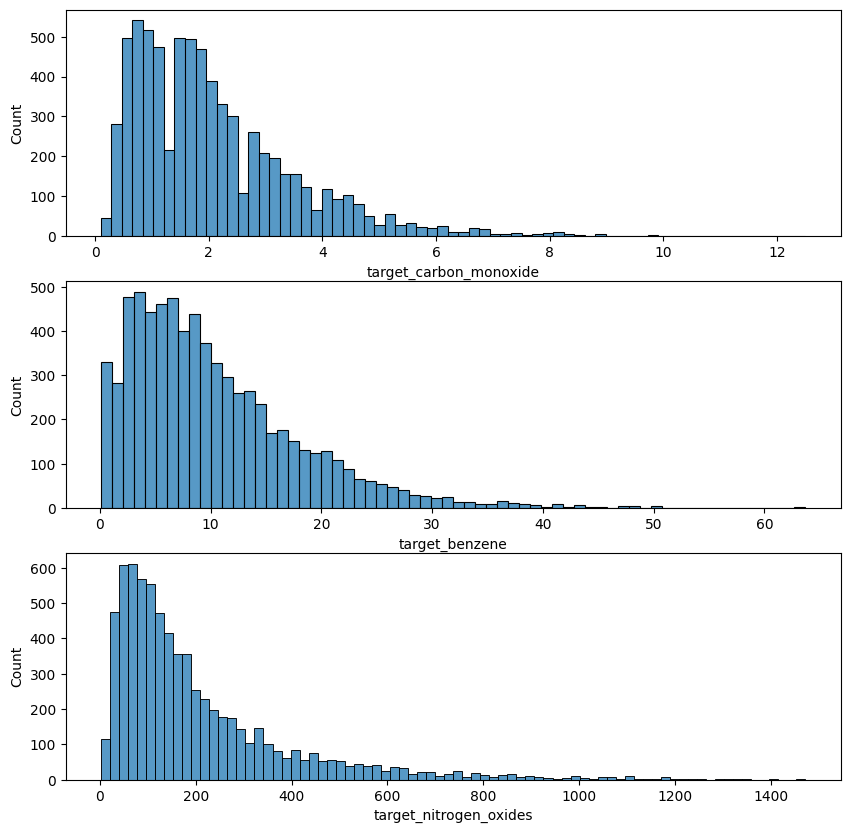

In [34]:
# Veamos nuestras variables objetivo
fig, axs = plt.subplots(3,1,figsize=(10,10))
n=0
for target in targets:
    sns.histplot(train_data[target], ax=axs[n])
    n+=1
plt.show()

> Vemos que nuestras variables están sesgadas, en este caso se pueden utilizar varios formas de escalado pero especificamente usaremos `log scaling`

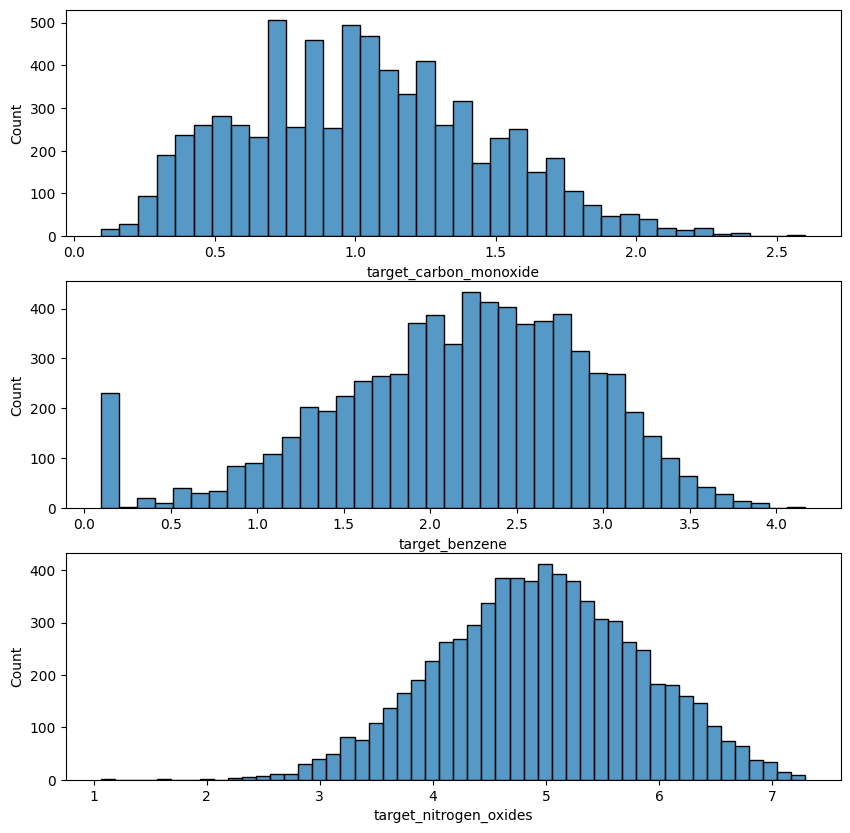

In [35]:
# Nuestra función de escalado
def scaler(col):
    col = np.log1p(col)
    return col

# Se lo aplicamos nuestras variables objetivo
for target in targets:
    train_data_featured[target] = scaler(train_data_featured[target])

# Graficamos
fig, axs = plt.subplots(3,1,figsize=(10,10))
n=0
for target in targets:
    sns.histplot(train_data_featured[target], ax=axs[n])
    n+=1
plt.show()

> Podemos aplicarle ahora un standard o min-max scaler para que mantenga una escala compartida? Que opinas?

<Axes: >

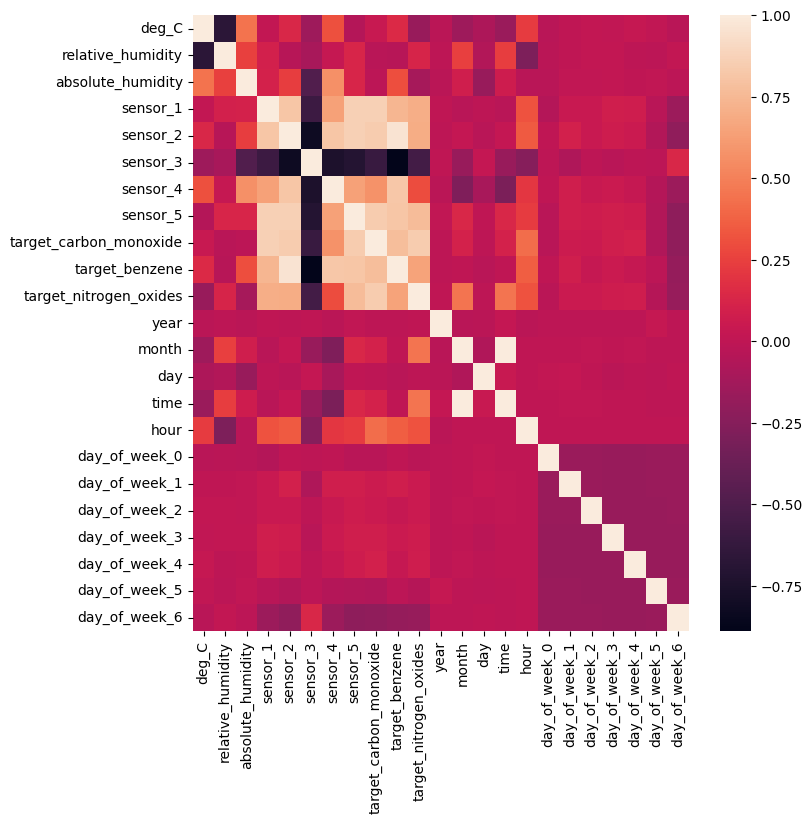

In [44]:
plt.figure(figsize=(8,8))
sns.heatmap(train_data_featured.corr())

> El sensor 3 se comporta de manera distinta a los demás. Esto es algo importante para el modelado?

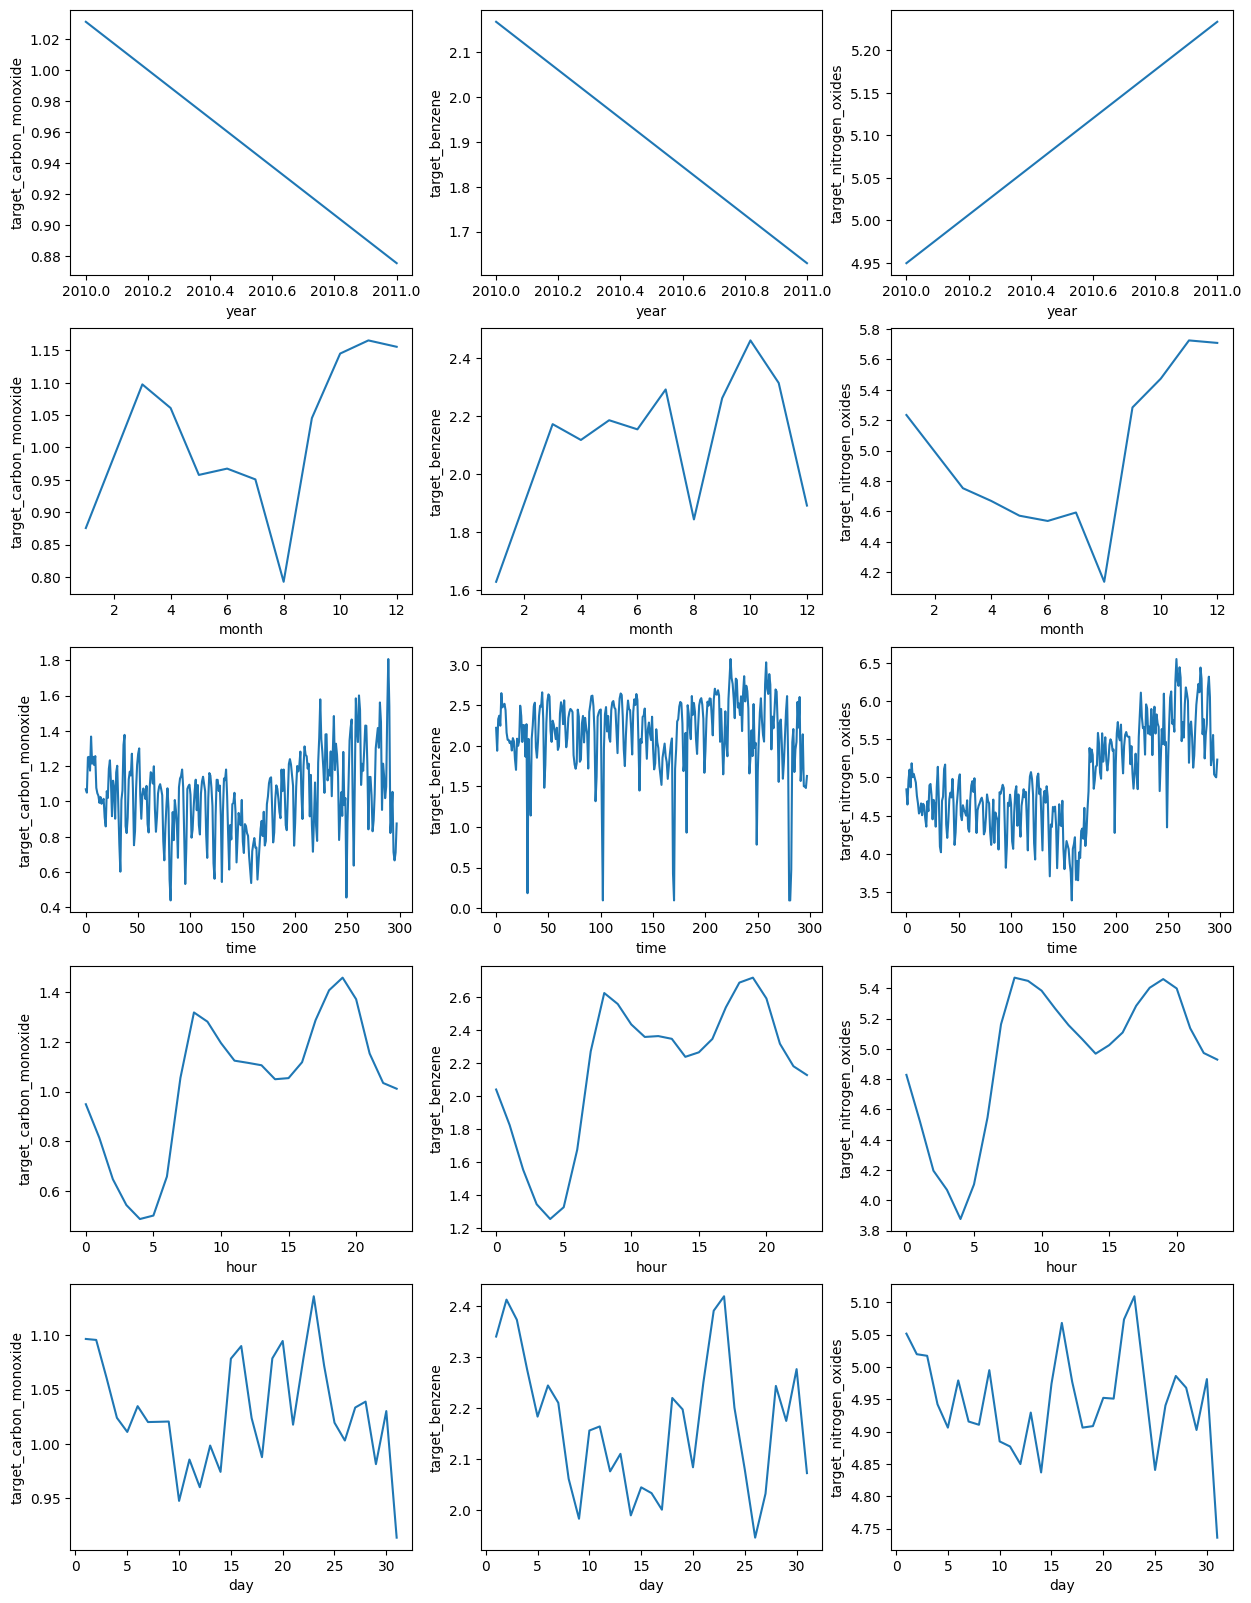

In [45]:
time_columns = ["year","month","time","hour","day"]
fig,axs = plt.subplots(5,3,figsize=(15,20))
k=0
for time in time_columns:
    n=0
    for target in targets:
        sns.lineplot(train_data_featured.groupby(train_data_featured[time])[target].mean() ,ax=axs[k,n])
        n+=1
    k+=1
plt.show()

> Encuentras patrones que nos podrían ayudar?

#### **Modelamiento**

In [50]:
# Antes de iniciar el modelado transformamos de una vez los datos de test
test_data_featured = date_features(test_data)
test_data_featured.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2247 entries, 0 to 2246
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   deg_C              2247 non-null   float64
 1   relative_humidity  2247 non-null   float64
 2   absolute_humidity  2247 non-null   float64
 3   sensor_1           2247 non-null   float64
 4   sensor_2           2247 non-null   float64
 5   sensor_3           2247 non-null   float64
 6   sensor_4           2247 non-null   float64
 7   sensor_5           2247 non-null   float64
 8   year               2247 non-null   int32  
 9   month              2247 non-null   int32  
 10  day                2247 non-null   int32  
 11  time               2247 non-null   int64  
 12  hour               2247 non-null   int32  
 13  day_of_week_0      2247 non-null   int64  
 14  day_of_week_1      2247 non-null   int64  
 15  day_of_week_2      2247 non-null   int64  
 16  day_of_week_3      2247 

##### **Modelo AutoML**

In [51]:
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_squared_log_error

def flaml_model(train, targets, test, time_budget=120, metric="rmse"):
    print('Setting up data...')
    X_train = train.drop(columns=targets)
    y_train = train[targets]
    X_test = test.drop(columns=targets, errors='ignore')

    print('Training AutoML per target...')
    models = {}
    predictions = {}

    for target in targets:
        print(f'\n--- Training for: {target} ---')
        automl = AutoML()
        automl.fit(
            X_train, y_train[target],
            task="regression",
            metric=metric,         # "rmse", "mae", "r2", "mse"
            time_budget=time_budget,  # seconds per target
            verbose=1
        )
        print(f'Best model for {target}: {automl.best_estimator}')
        models[target] = automl
        predictions[target] = automl.predict(X_test)

    print('\nDone!')

    # Build results dataframe
    results = test.copy()
    for target in targets:
        results[target] = predictions[target]

    return results, models

In [52]:
targets =["target_carbon_monoxide","target_benzene","target_nitrogen_oxides"]

results, models = flaml_model(
    train=train_data_featured,
    targets=targets,
    test=test_data_featured,
    time_budget=120,
    metric="rmse"
)

Setting up data...
Training AutoML per target...

--- Training for: target_carbon_monoxide ---


INFO:flaml.tune.searcher.blendsearch:No low-cost partial config given to the search algorithm. For cost-frugal search, consider providing low-cost values for cost-related hps via 'low_cost_partial_config'. More info can be found at https://microsoft.github.io/FLAML/docs/FAQ#about-low_cost_partial_config-in-tune


Best model for target_carbon_monoxide: lgbm

--- Training for: target_benzene ---


INFO:flaml.tune.searcher.blendsearch:No low-cost partial config given to the search algorithm. For cost-frugal search, consider providing low-cost values for cost-related hps via 'low_cost_partial_config'. More info can be found at https://microsoft.github.io/FLAML/docs/FAQ#about-low_cost_partial_config-in-tune


Best model for target_benzene: extra_tree

--- Training for: target_nitrogen_oxides ---


INFO:flaml.tune.searcher.blendsearch:No low-cost partial config given to the search algorithm. For cost-frugal search, consider providing low-cost values for cost-related hps via 'low_cost_partial_config'. More info can be found at https://microsoft.github.io/FLAML/docs/FAQ#about-low_cost_partial_config-in-tune


Best model for target_nitrogen_oxides: xgboost

Done!


In [71]:
from sklearn.model_selection import cross_validate
from sklearn.metrics import make_scorer, mean_squared_error, r2_score


def compare_flaml_results(models, targets, train, fold=3):
    X = train.drop(columns=targets)

    for target in targets:
        print(f"\n{'='*60}")
        print(f"  Target: {target}")
        print(f"{'='*60}")

        automl = models[target]
        y = train[target]
        rows = []

        for estimator, loss in automl.best_loss_per_estimator.items():
            try:
                # Get the best model for this estimator
                best_model = automl.best_model_for_estimator(estimator)

                cv = cross_validate(best_model, X, y, cv=fold, scoring={
                    "RMSE": make_scorer(mean_squared_error, greater_is_better=False),
                    "R2":   make_scorer(r2_score)
                }, n_jobs=-1)

                rmse = round(np.sqrt(-cv["test_RMSE"].mean()), 4)
                r2   = round(cv["test_R2"].mean(), 4)

            except Exception as e:
                rmse, r2 = None, None

            rows.append({
                "Model":          estimator,
                "Best Val Loss":  round(loss, 4),
                "RMSE (CV)":      rmse,
                "R2 (CV)":        r2,
            })

        df = pd.DataFrame(rows).sort_values("Best Val Loss").reset_index(drop=True)

        display(df.style
            .highlight_min(subset=["Best Val Loss", "RMSE (CV)"], color="green")
            .highlight_max(subset=["R2 (CV)"], color="green")
            .format(precision=4, na_rep="N/A"))

        print(f"\nFinal Best Model: {automl.best_estimator} | Loss: {round(automl.best_loss, 4)} | Time: {round(automl.time_to_find_best_model, 2)}s")

In [72]:
compare_flaml_results(models, targets, train=train_data_featured, fold=3)


  Target: target_carbon_monoxide


,Model,Best Val Loss,RMSE (CV),R2 (CV)
0,lgbm,0.0937,0.1458,0.8836
1,xgboost,0.0972,0.1490,0.8789
2,extra_tree,0.1057,0.1568,0.8676
3,xgb_limitdepth,0.1098,0.1594,0.8583
4,rf,0.1184,0.1669,0.8495
5,sgd,0.1773,0.2058,0.7463



Final Best Model: lgbm | Loss: 0.0937 | Time: 56.54s

  Target: target_benzene


,Model,Best Val Loss,RMSE (CV),R2 (CV)
0,extra_tree,0.0845,0.1042,0.9813
1,lgbm,0.0848,0.1095,0.9792
2,xgb_limitdepth,0.0885,0.1036,0.9813
3,rf,0.0923,0.1037,0.9813
4,xgboost,0.1028,0.1105,0.9788
5,sgd,0.1217,0.1498,0.9615



Final Best Model: extra_tree | Loss: 0.0845 | Time: 125.33s

  Target: target_nitrogen_oxides


,Model,Best Val Loss,RMSE (CV),R2 (CV)
0,xgboost,0.1985,0.3543,0.7752
1,extra_tree,0.1994,0.4432,0.6612
2,lgbm,0.2000,0.3937,0.7287
3,rf,0.2220,0.4418,0.6613
4,xgb_limitdepth,0.2264,0.4104,0.7029
5,sgd,0.3727,0.4627,0.6246



Final Best Model: xgboost | Loss: 0.1985 | Time: 117.59s


In [69]:
def compare_flaml_models(models, targets):
    print("Model Comparison - - - - - - - - - - - - - - - - - - - -\n")
    comparison = []

    for target in targets:
        automl = models[target]
        comparison.append({
            "Target": target,
            "Best Model": automl.best_estimator,
            "Best Loss (CV)": round(automl.best_loss, 4),
            "Training Time (s)": round(automl.time_to_find_best_model, 2)
        })

    df = pd.DataFrame(comparison)
    print(df.to_string(index=False))
    return df


def plot_feature_importance(models, targets, feature_names, top_n=10):
    for target in targets:
        automl = models[target]
        best = automl.model.estimator  # get the underlying sklearn model

        # Check if model has feature importances
        if hasattr(best, 'feature_importances_'):
            importances = best.feature_importances_
        elif hasattr(best, 'coef_'):
            importances = np.abs(best.coef_)
        else:
            print(f"No feature importance available for {target} ({automl.best_estimator})")
            continue

        # Sort and plot top N
        indices = np.argsort(importances)[::-1][:top_n]
        plt.figure(figsize=(10, 5))
        plt.title(f"Feature Importance — {target} ({automl.best_estimator})")
        plt.bar(range(top_n), importances[indices])
        plt.xticks(range(top_n), [feature_names[i] for i in indices], rotation=45, ha='right')
        plt.tight_layout()
        plt.show()

Model Comparison ---

                Target Best Model  Best Loss (CV)  Training Time (s)
target_carbon_monoxide       lgbm          0.0937              56.54
        target_benzene extra_tree          0.0845             125.33
target_nitrogen_oxides    xgboost          0.1985             117.59


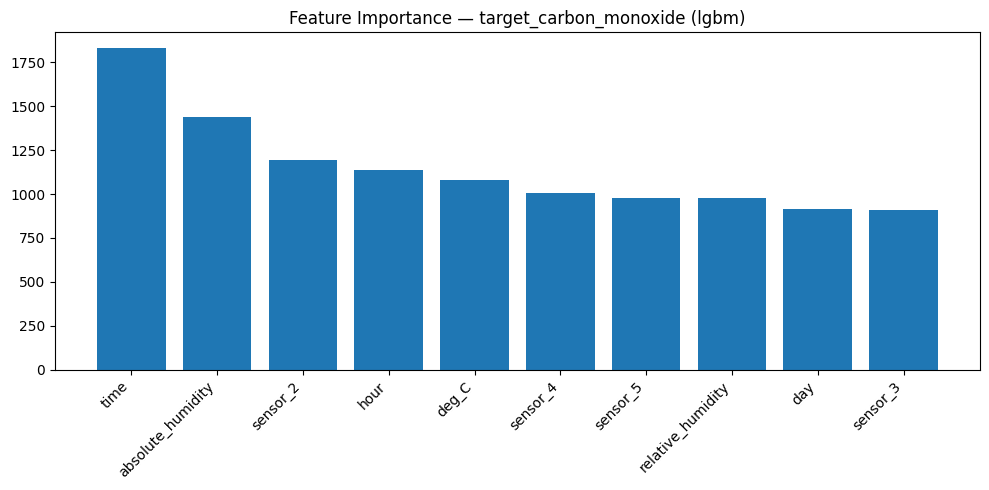

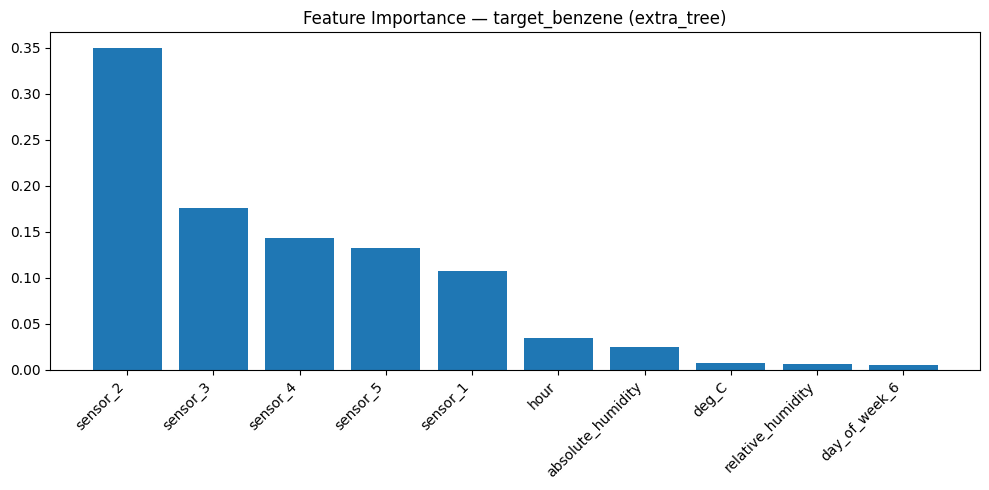

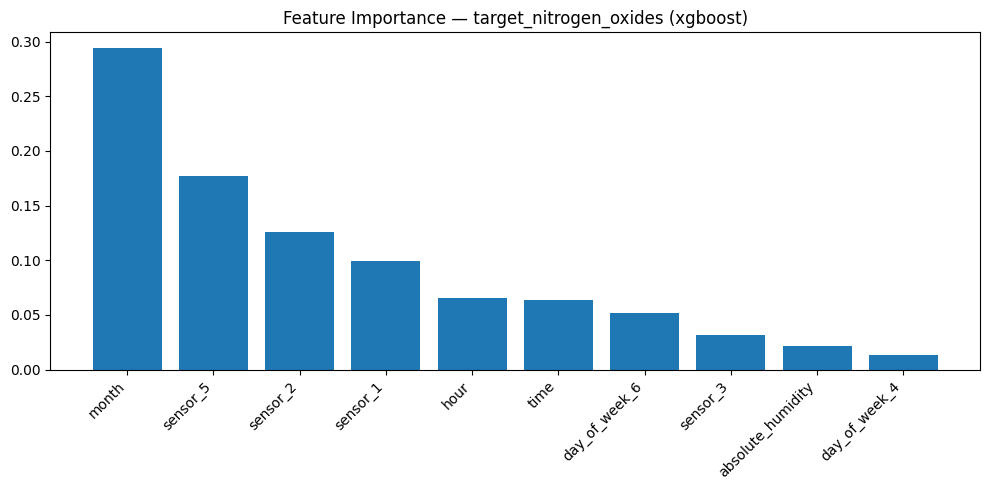

In [70]:
feature_names = train_data_featured.drop(columns=targets).columns.tolist()

compare_flaml_models(models, targets)
plot_feature_importance(models, targets, feature_names, top_n=10)

### **3. Taller Bono**

Sobre este mismo laboratorio responda y desarrolle los siguientes puntos.

1. Realiza transformaciones adicionales a los datos (si lo consideras necesario). Por ejemplo la escala de los datos, correlaciones, variables adicionales, etc... Y reentrena usando AutoML, que diferencias encontraron? **Realiza un cuadro comparativo con el modelo base y el modelo reentrenado por ustedes.**

2. De esos modelos seleccionados para cada target **explica el por qué ese es el mejor y no otro tipo de modelo**. Puedes basarte en la teoría de cada algoritmo o el contexto del negocio.

3. Dado que las variables objetivo están correlacionadas, realiza un entrenamiento encadenado; Usa las predicciones del punto 1 de `target_carbon_monoxide` y `target_benzene` y úsalas como variables adicionales en el entrenamiento de `target_nitrogen_oxides`. Compara el RMSE y R2 del modelo encadenado contra el modelo construido para `target_nitrogen_oxides` en el punto 1. La correlación ayuda en su predicción y rendimiento?